# Importing 


In [30]:
import cv2
from pathlib import Path
import pandas as pd 
from text_cleaner import TextCleaner
import matplotlib.pyplot as plt
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.inception_v3 import (
    InceptionV3,
    preprocess_input,
)
from tensorflow.keras.preprocessing import image

random.seed(42)


script_path = Path.cwd()
images_folder_path = script_path.joinpath("Images")
# print (images_folder_path)
images_paths = list(images_folder_path.glob("*.jpg"))

captions_df = pd.read_csv("captions.csv")

print(captions_df.shape)
print(captions_df.isna().sum())
# print(captions_df.head(5))



I0000 00:00:1787864360.509250   90097 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787864360.698512   90097 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787864361.894819   90097 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


(40455, 2)
image      0
caption    0
dtype: int64


## Helpers


In [21]:
#since my opencv doesn't have GUI and i don't have time to go through this process i'll use matplotlip for visuals
def matplot_show(image) :
    image = cv2.cvtColor(image , cv2.COLOR_BGR2RGB)
    plt.imshow(image)
    plt.axis("off")
    plt.show()

# Phase 1 :Dataset

## Preprocessing


In [14]:
#keeping names to connect them later to the texts
images = {image_path.name : cv2.imread(str(image_path)) for image_path in images_paths}
#removing none image
images = {name : image for name,image in images.items() if image is not None}


#
# clean the caption text
cleaner = TextCleaner(str_series= captions_df["caption"])
cleaned_captions = cleaner.clean_series()
captions_df = captions_df.loc[cleaned_captions.index].assign(caption=cleaned_captions)

captions_dict = captions_df.groupby("image")["caption"].apply(list).to_dict()
print (captions_dict["3488512097_e500cb499f.jpg"])


Text cleaned
['a man dressed in gray gear including helmet races a dirt bike on a dirt track', 'a man in a black uniform and helmet dirtracing with his bike s front wheel in midair', 'a man riding a dirt bike', 'a motorcycle racer is in action at the track', 'biker riding dirt bike on dirt track']


## Connecting each image name with image and captions

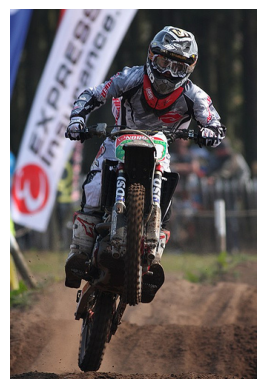

In [17]:

image_text_merged = {}
for img_name, image in images.items():
    image_captions = captions_dict.get(img_name)
    
    if image_captions is None:
        print(f"Warning: no captions found for {img_name}")
        continue

    image_text_merged[img_name] = {
        "image": image,
        "captions": image_captions
    }

image = image_text_merged["3488512097_e500cb499f.jpg"]["image"]
matplot_show(image=image)

## Data Splitting 

In [28]:
items = list(image_text_merged.items())
random.shuffle(items)

total_len = len(items)
train_size = int(total_len * 0.8)
val_size = int(total_len * 0.1)


train_set = items[:train_size]
valid_set = items[train_size : train_size + val_size]
test_set  = items[train_size + val_size : ]

#converting back to dicts
train_dict = dict(train_set)
val_dict = dict(valid_set)
test_dict = dict(test_set)


##checking against leakage 
assert set(train_dict) & set(val_dict) == set()
assert set(train_dict) & set(test_dict)  == set()
assert set(val_dict)   & set(test_dict)  == set()

print(len(train_dict), len(val_dict), len(test_dict))

6472 809 810


# Phase 2 :Image feature Extraction 